<a href="https://colab.research.google.com/github/EdwinZhanCN/Projects-in-ML-and-AI/blob/main/homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 2

In this homework, I will use the Jena Climate Dataset. The model will use the temperature data in past several hours to predict the temperature in the future

In [59]:
# Load dataset
!wget -q https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q -o jena_climate_2009_2016.csv.zip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

print(df.head())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

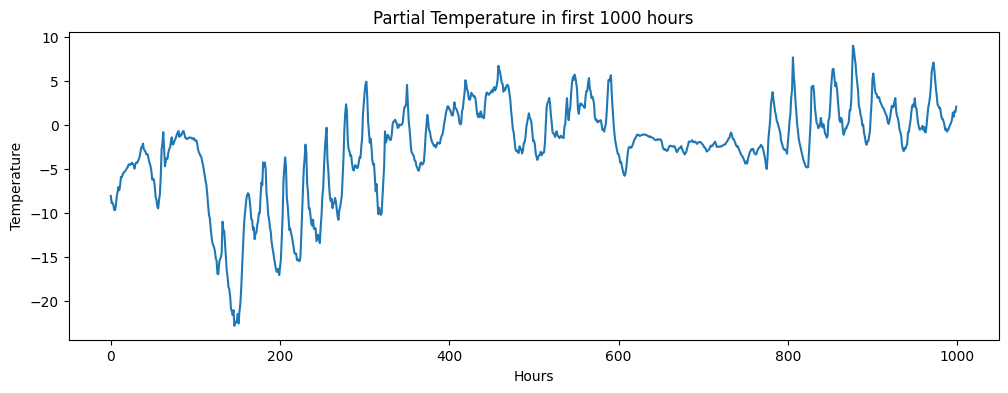

Normalized Shape: (70091, 3)


In [60]:
# Data Visualization

df_hourly = df[5::6].reset_index(drop=True)
features = ['T (degC)', 'p (mbar)', 'rh (%)']
data = df_hourly[features].values

plt.figure(figsize=(12, 4))
plt.plot(data[:1000, 0])
plt.title("Partial Temperature in first 1000 hours")
plt.xlabel("Hours")
plt.ylabel("Temperature")
plt.show()

train_split = int(0.7 * len(data))
train_data = data[:train_split]

mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

data_normalized = (data - mean) / std
print(f"Normalized Shape: {data_normalized.shape}")

### Part 1 - Implement RNN

In [61]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class RNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1, num_layers=1):
        super(RNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, h_n = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out


def create_sequences(data, seq_length, target_col_idx=0):
    xs = []
    ys = []
    # use past data (determined by seq_length) to predict next 1 hour.
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length, target_col_idx]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 24*7 # Past 7 days

X, y = create_sequences(data_normalized, seq_length)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1) # (N, 1)

# 70% train, 15% val, 15% test
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

batch_size = 256
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(X_train)}, Val samples: {len(X_val)}, Test samples: {len(X_test)}")

Train samples: 48946, Val samples: 10488, Test samples: 10489


Model structure:
- `nn.RNN` use `tanh` as the default hidden layer activation function.
- Output layer is a fully connected layer using `nn.Linear`, it has no activation function.

We will use Mean Squared Error as the model performance metrics.

In [62]:
input_dim = len(features)
hidden_dim = 32
RNNModel = RNN(input_dim, hidden_dim)

criterion = nn.MSELoss()
rnn_optimizer = torch.optim.Adam(RNNModel.parameters(), lr=0.001)
device = torch.device("cuda")
RNNModel = RNNModel.to(device)

epochs = 15

def train_process(epochs, model, optimizer_inst):
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
      model.train()
      running_loss = 0.0

      for inputs, targets in train_loader:
          inputs, targets = inputs.to(device), targets.to(device)
          outputs = model(inputs)
          loss = criterion(outputs, targets)

          optimizer_inst.zero_grad()
          loss.backward()
          optimizer_inst.step()

          running_loss += loss.item() * inputs.size(0)

      epoch_train_loss = running_loss / len(train_loader.dataset)
      train_losses.append(epoch_train_loss)

      model.eval()
      running_val_loss = 0.0
      with torch.no_grad():
          for inputs, targets in val_loader:
              inputs, targets = inputs.to(device), targets.to(device)
              outputs = model(inputs)
              val_loss = criterion(outputs, targets)
              running_val_loss += val_loss.item() * inputs.size(0)

      epoch_val_loss = running_val_loss / len(val_loader.dataset)
      val_losses.append(epoch_val_loss)
  return train_losses, val_losses

train_losses_rnn, val_losses_rnn = train_process(epochs, RNNModel, rnn_optimizer)

#### Visualization

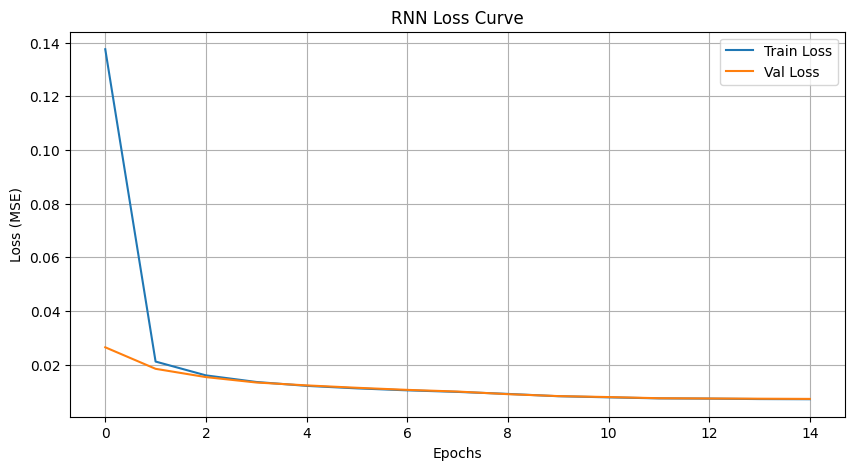

====== Test Loss ======: 0.0063


In [63]:
def loss_eval(model, title, train_losses_param, val_losses_param):
  plt.figure(figsize=(10, 5))
  plt.plot(train_losses_param, label='Train Loss')
  plt.plot(val_losses_param, label='Val Loss')
  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel('Loss (MSE)')
  plt.legend()
  plt.grid(True)
  plt.show()

  model.eval()
  test_loss = 0.0
  with torch.no_grad():
      for inputs, targets in test_loader:
          inputs, targets = inputs.to(device), targets.to(device)
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          test_loss += loss.item() * inputs.size(0)
  final_test_mse = test_loss / len(test_loader.dataset)
  print(f"====== Test Loss ======: {final_test_mse:.4f}")

loss_eval(RNNModel, 'RNN Loss Curve', train_losses_rnn, val_losses_rnn)

### Part 2 LSTM & GRU Comparison

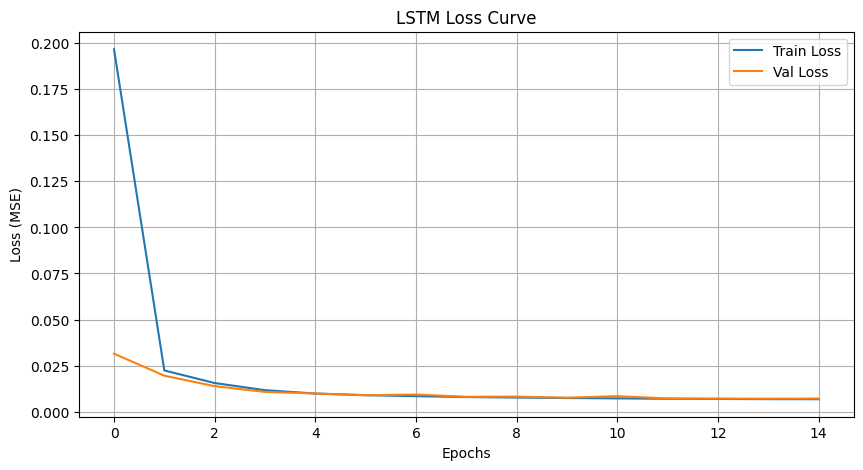

====== Test Loss ======: 0.0061


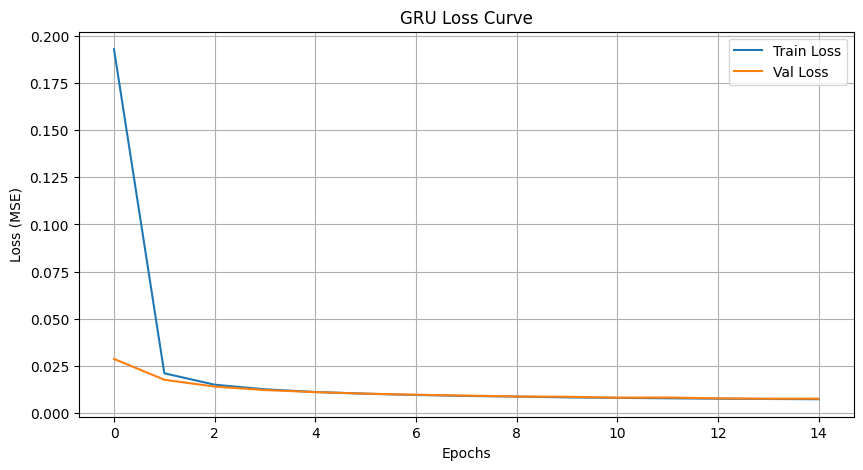

====== Test Loss ======: 0.0066


In [64]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1, num_layers=1):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1, num_layers=1):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, h_n = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

LSTMModel = LSTM(input_dim, hidden_dim)
GRUModel = GRUModel(input_dim, hidden_dim)

criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(LSTMModel.parameters(), lr=0.001)
device = torch.device("cuda")
LSTMModel = LSTMModel.to(device)

gru_optimizer = torch.optim.Adam(GRUModel.parameters(), lr=0.001)
device = torch.device("cuda")
GRUModel = GRUModel.to(device)

lstm_train_losses, lstm_val_losses = train_process(epochs, LSTMModel, lstm_optimizer)
gru_train_losses, gru_val_losses = train_process(epochs, GRUModel, gru_optimizer)

loss_eval(LSTMModel, 'LSTM Loss Curve', lstm_train_losses, lstm_val_losses)
loss_eval(GRUModel, 'GRU Loss Curve', gru_train_losses, gru_val_losses)

Conclusion:

I don't see major difference between 3 models, they have barely same loss curve and test loss. This may occurs because of short sequence length 24*7 (7 days) we used, it does not have major impact on RNN.

## Part 3

No, we cannot use trainditional feed-foward networks to solve this problem effeciently, like MLP, we must ensure the input is 1-D feature vector, we could flatten the sequnce data into normal features. But the networks loss the temporal order, the flattened sequnce data does not provide any order information, and of course the parameter for first input layer would be huge due to flattening.

## Task 3

I chose the GloVe embedding model because it is trained on global word-word co-occurrence matrices. And compared to large models like BERT, GloVe is significantly more lightweight and faster for inference and similarity calculations.

In [65]:
# Load model
%pip install gensim

### Part 1 - Implementing Word Embeddings

In [66]:
import numpy as np
import gensim.downloader as api

embed_model = api.load("glove-wiki-gigaword-50")

def get_word_embedding(word, model, n_gram=3):
    word = word.lower().strip()

    if word in model:
        return model[word]

    # OOV, use ngram subword to approximate.
    sub_words = [word[i:i+n_gram] for i in range(len(word)-n_gram+1)]

    valid_sub_words_vecs = [model[sw] for sw in sub_words if sw in model]

    if valid_sub_words_vecs:
        approx_vector = np.mean(valid_sub_words_vecs, axis=0)
        return approx_vector
    else:
        return np.zeros(model.vector_size)

word1 = input("first word: ")
word2 = input("second word: ")

vec1 = get_word_embedding(word1, embed_model)
vec2 = get_word_embedding(word2, embed_model)

print(f"\n'{word1}' embeddings: {vec1[:5]} ...")
print(f"'{word2}' embeddings: {vec2[:5]} ...")

first word: apple
second word: banana

'apple' embeddings: [ 0.52042 -0.8314   0.49961  1.2893   0.1151 ] ...
'banana' embeddings: [-0.25522 -0.75249 -0.86655  1.1197   0.12887] ...


To handle OOV words, my function breaks the word down into character n-grams (n = 3 here). It retrieves the embeddings for any known n-grams from the GloVe vocabulary and averages them.

## Part 2 - Cosine Similarity Computation

In [67]:
import numpy as np
from numpy.linalg import norm

def cosine_similarity(vec1, vec2):
    if norm(vec1) == 0 or norm(vec2) == 0:
        return 0.0
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

def batch_cosine_similarity(word_pairs, model):
    results = {}
    for w1, w2 in word_pairs:
        vec1 = get_word_embedding(w1, model)
        vec2 = get_word_embedding(w2, model)
        sim = cosine_similarity(vec1, vec2)
        results[f"{w1} vs {w2}"] = sim
    return results

pairs_to_test = [
    ("king", "queen"),
    ("dog", "cat"),
    ("computer", "software"),
    ("apple", "car"),
    ("happy", "sad")
    ]

batch_results = batch_cosine_similarity(pairs_to_test, embed_model)
for pair, sim in batch_results.items():
    print(f"{pair}: {sim:.4f}")

king vs queen: 0.7839
dog vs cat: 0.9218
computer vs software: 0.8815
apple vs car: 0.3952
happy vs sad: 0.6891


#### Visualization

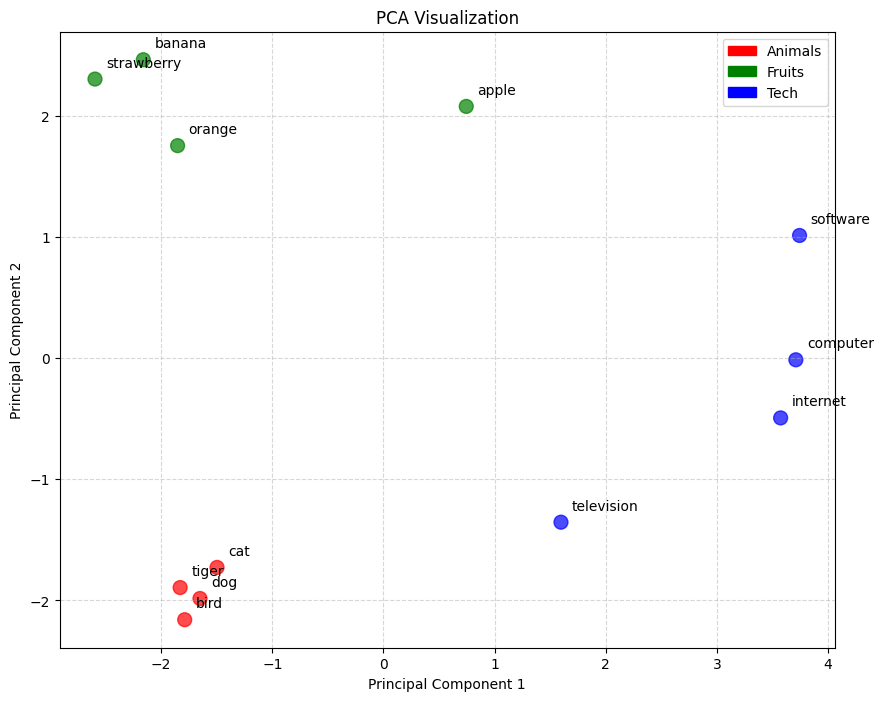

In [68]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

word_clusters = {
    "Animals": ["dog", "cat", "bird", "tiger"],
    "Fruits": ["apple", "banana", "orange","strawberry"],
    "Tech": ["computer", "software", "television", "internet"]
}

all_words = []
all_vectors = []
colors = []
cluster_colors = {"Animals": "red", "Fruits": "green", "Tech": "blue"}

for category, words in word_clusters.items():
    for word in words:
        vec = get_word_embedding(word, embed_model)
        # ignore 0 vectors
        if np.any(vec):
            all_words.append(word)
            all_vectors.append(vec)
            colors.append(cluster_colors[category])

all_vectors = np.array(all_vectors)

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(all_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=colors, s=100, alpha=0.7)

for i, word in enumerate(all_words):
    plt.annotate(word, (vectors_2d[i, 0] + 0.1, vectors_2d[i, 1] + 0.1), fontsize=10)

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in cluster_colors.items()]
plt.legend(handles=legend_patches, loc='best')

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The objective of word embedding is to identify the high dimensional meaning between words, in NLP, if we use Euclidean distance to measure the similarity of words, it heavily impacted by the magnitude, that is, word frequency, that's not what we want. So we choose cosine similarity which ignores magnitude by comparing the angle between vectors.

### Part 3 - Designing a Novel Dissimilarity Metric



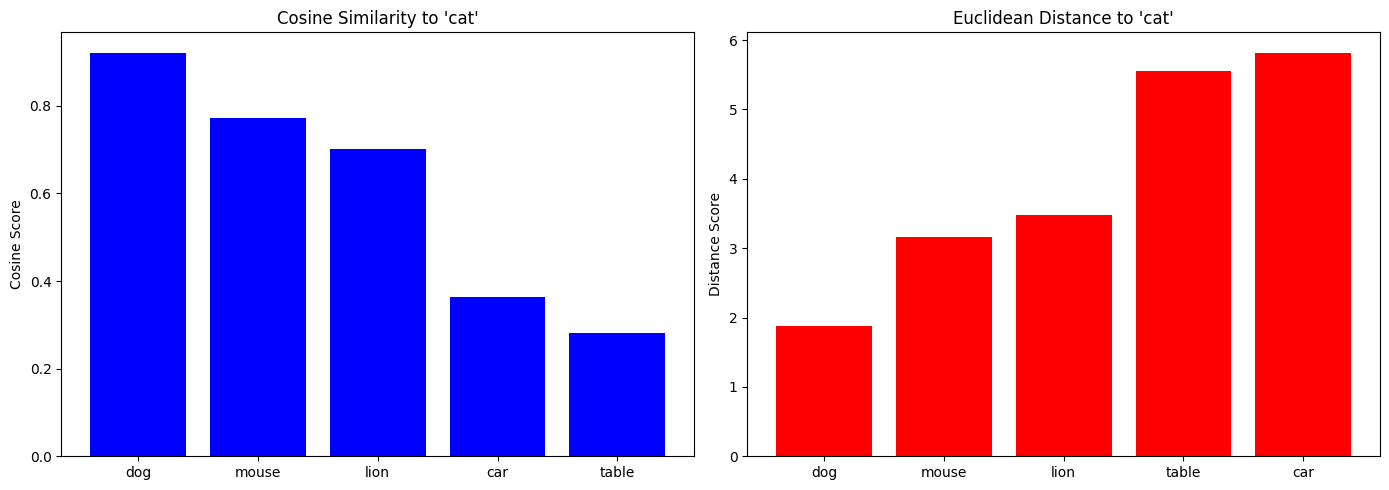

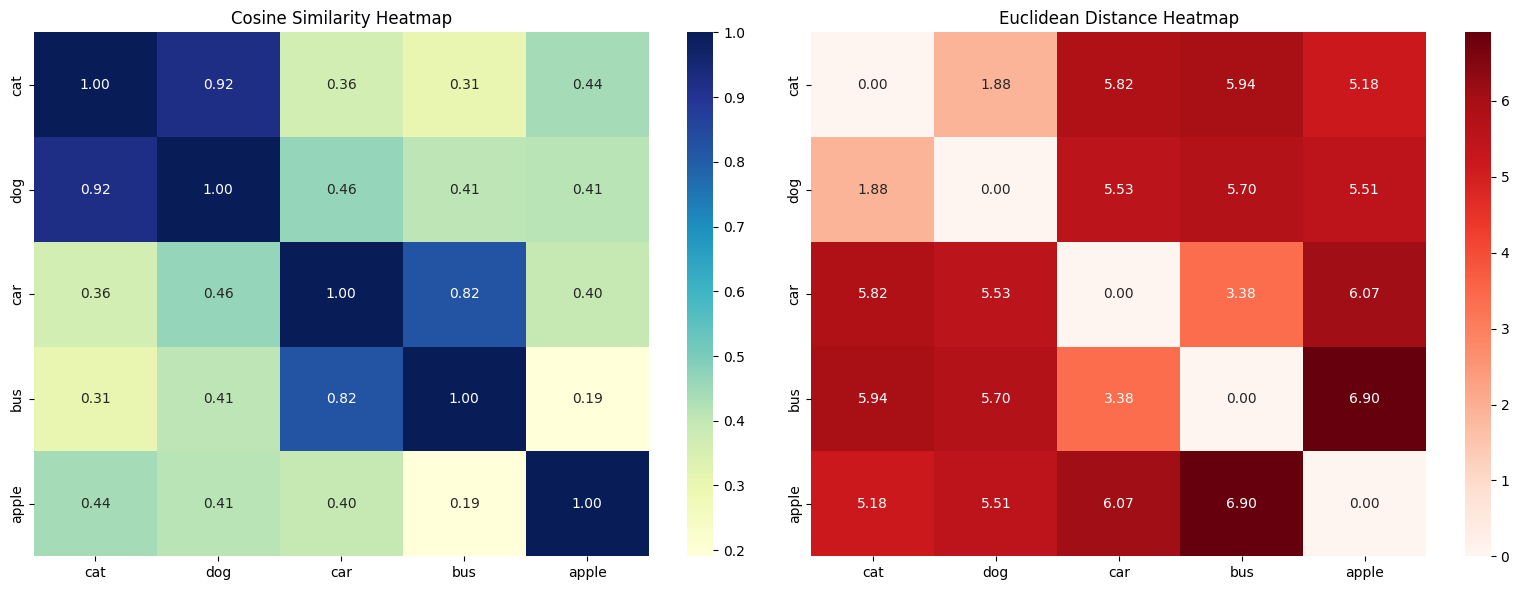

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_metric(vec1, vec2, metric='cosine'):
    if metric == 'cosine':
        if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
            return 0.0
        return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

    elif metric == 'euclidean':
        return np.linalg.norm(vec1 - vec2)

    else:
        raise ValueError("Not supported")

def plot_word_rankings(target_word, candidate_words, model):
    target_vec = get_word_embedding(target_word, model)

    cos_scores = []
    euc_scores = []

    for word in candidate_words:
        vec = get_word_embedding(word, model)
        cos_scores.append(compute_metric(target_vec, vec, metric='cosine'))
        euc_scores.append(compute_metric(target_vec, vec, metric='euclidean'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    cos_sorted_indices = np.argsort(cos_scores)[::-1]
    axes[0].bar([candidate_words[i] for i in cos_sorted_indices],
                [cos_scores[i] for i in cos_sorted_indices], color='blue')
    axes[0].set_title(f"Cosine Similarity to '{target_word}'")
    axes[0].set_ylabel("Cosine Score")


    euc_sorted_indices = np.argsort(euc_scores)
    axes[1].bar([candidate_words[i] for i in euc_sorted_indices],
                [euc_scores[i] for i in euc_sorted_indices], color='red')
    axes[1].set_title(f"Euclidean Distance to '{target_word}'")
    axes[1].set_ylabel("Distance Score")

    plt.tight_layout()
    plt.show()

target = "cat"
candidates = ["dog", "lion", "table", "car", "mouse"]
plot_word_rankings(target, candidates, embed_model)

def plot_heatmap(words, model):
    n = len(words)
    cos_matrix = np.zeros((n, n))
    euc_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            vec_i = get_word_embedding(words[i], model)
            vec_j = get_word_embedding(words[j], model)
            cos_matrix[i, j] = compute_metric(vec_i, vec_j, metric='cosine')
            euc_matrix[i, j] = compute_metric(vec_i, vec_j, metric='euclidean')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cos_matrix, annot=True, xticklabels=words, yticklabels=words,
                cmap="YlGnBu", ax=axes[0], fmt=".2f")
    axes[0].set_title("Cosine Similarity Heatmap")

    sns.heatmap(euc_matrix, annot=True, xticklabels=words, yticklabels=words,
                cmap="Reds", ax=axes[1], fmt=".2f")
    axes[1].set_title("Euclidean Distance Heatmap")

    plt.tight_layout()
    plt.show()

word_list = ["cat", "dog", "car", "bus", "apple"]
plot_heatmap(word_list, embed_model)

Interestingly, using Euclidean Distance as my custom dissimilarity metric is not that bad compare to consine similarity. It accounts for both the angle and the magnitude. Euclidean distance successfully captures the divergence in word usage frequency, as heatmap shown above, providing an another perspective. But I still prefer consine similarity in some expertised context.